# 06 — POST episode contrasts: e1/e2/e3

This notebook tests whether POST-viewing responses differ between old images encoded in different island episodes:

- episode 1 (`e1`),
- episode 2 (`e2`),
- episode 3 (`e3`),
- and new control images.

It is a **POST-only** analysis. The first-level GLM contains one viewing run from the POST session and models:

```text
post_e1
post_e2
post_e3
post_new
```

The notebook is restart-safe:

- first-level maps are saved immediately;
- `RUN_FIRST_LEVEL=False` loads/verifies existing maps;
- `OVERWRITE_FIRST_LEVEL=False` runs only missing subjects;
- all figures use the common high-resolution mean T1w anatomical background from Notebook 00, passed directly as `bg_img`.


In [1]:
# ============================================================
# 1. Setup
# ============================================================

from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from nilearn.image import load_img
from nilearn.plotting import plot_design_matrix

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_colwidth", 180)

PROJECT_ROOT = Path("/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project")
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from island_glm.paths import ProjectPaths, make_analysis_dirs
from island_glm.common import load_common_inputs, get_pre_post_subjects
from island_glm.events import (
    save_post_episode_subject_events,
    build_post_episode_event_qc,
    make_post_episode_events,
)
from island_glm.contrasts import (
    make_post_episode_contrasts,
    contrast_specs_to_table,
)
from island_glm.first_level import run_post_episode_first_level_subject
from island_glm.second_level import (
    first_level_map_path,
    verify_first_level_maps,
    run_second_level_all_contrasts,
    threshold_group_maps,
    make_cluster_tables,
)
from island_glm.reporting import label_cluster_table
from island_glm.plotting import plot_group_stat_map, make_interactive_view

ANALYSIS_NAME = "post_episode_e1_e2_e3_viewing_glm"
SMOOTHING_FWHM = 5.0
SMOOTHING_LABEL = "smoothed5mm"
TEST_SUBJECT = "sub-P15"

# ------------------------------------------------------------
# Runtime flags
# ------------------------------------------------------------

# First run of this new notebook: keep RUN_FIRST_LEVEL=True.
# After all maps are saved successfully, change it to False.
RUN_FIRST_LEVEL = True
OVERWRITE_FIRST_LEVEL = True

RUN_SECOND_LEVEL = True
OVERWRITE_SECOND_LEVEL = True

USE_MEAN_T1W_BACKGROUND = True

paths = ProjectPaths.from_root(PROJECT_ROOT)
dirs = make_analysis_dirs(paths, ANALYSIS_NAME, smoothing_label=SMOOTHING_LABEL)

print("Project root:", paths.project_root)
print("Analysis output:", dirs["out"])
print("dirs keys:", sorted(dirs.keys()))


Project root: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project
Analysis output: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm
dirs keys: ['cluster_tables', 'events', 'figures', 'first_level', 'first_level_designs', 'first_level_figures', 'first_level_maps', 'interactive', 'out', 'restart', 'second_level', 'second_level_maps', 'tables', 'thresholded_maps']


## Load common inputs from Notebook 00

Notebook 00 defines the final subject list, viewing item labels, filename parsing, episode labels, checkpoint labels, and the common mean T1w anatomical background.


In [2]:
# ============================================================
# 2. Load common inputs and mean T1w background
# ============================================================

manifest, subject_table, viewing_item_labels = load_common_inputs(paths)
subjects = get_pre_post_subjects(manifest, no_high_motion=False)
sensitivity_subjects = get_pre_post_subjects(manifest, no_high_motion=True)

sessions = manifest["sessions"]

print("Main sample N:", len(subjects))
print("Sensitivity no-high-motion N:", len(sensitivity_subjects))
print("Sessions:", sessions)

assert "mean_anat" in manifest, (
    "Mean anatomical background missing from manifest. "
    "Rerun Notebook 00 after adding the mean T1w section."
)

mean_t1w_path = Path(manifest["mean_anat"]["mean_t1w_path"])
assert mean_t1w_path.exists(), f"Missing mean T1w file: {mean_t1w_path}"
mean_t1w_img = load_img(str(mean_t1w_path))

print("\nLoaded mean T1w anatomical background:")
print(mean_t1w_path)
print("Mean T1w shape:", mean_t1w_img.shape)

display(subject_table)
display(viewing_item_labels.head())

required_columns = {"subject", "phase", "onset", "duration", "old_new", "episode"}
missing_columns = required_columns.difference(viewing_item_labels.columns)
assert not missing_columns, f"Missing expected columns in viewing_item_labels: {missing_columns}"


Main sample N: 27
Sensitivity no-high-motion N: 25
Sessions: {'pre': 'ses-01', 'post': 'ses-05', 'task': 'viewing', 'run': '01', 'bold_space': 'MNI152NLin2009cAsym'}

Loaded mean T1w anatomical background:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/common_inputs/mean_anat/mean_T1w_prepost_N27_subjects_MNI152NLin2009cAsym.nii.gz
Mean T1w shape: (193, 229, 193)


,subject,included_primary_post_only,included_pre_post_N27,included_pre_post_no_high_motion_N25,excluded_from_pre_post,high_motion_flag,exclusion_reason
0,sub-P10,True,True,True,False,False,NaN
1,sub-P12,True,True,True,False,False,NaN
2,sub-P13,True,True,True,False,False,NaN
3,sub-P14,True,True,True,False,False,NaN
4,sub-P15,True,True,True,False,False,NaN
5,sub-P16,True,True,True,False,False,NaN
6,sub-P17,True,True,True,False,False,NaN
7,sub-P18,True,True,True,False,False,NaN
8,sub-P19,True,True,False,False,True,High-motion sensitivity exclusion.
9,sub-P21,True,True,False,False,True,High-motion sensitivity exclusion.


,subject,session,run,onset,duration,image_file,source_image_column,phase,theme,item_id,episode,episode_number,checkpoint_index,checkpoint_index_out_of,checkpoint_third,relevance_from_filename,object_category_from_filename,old_new,stimulus_version,relevance_condition,spatial_accuracy_z,spatial_accuracy_condition_centered,relevance,encoding_phase_third
0,sub-P10,ses-01,1,4.634,3.017,maya_3_e3_6_r_h_v1_old,event,pre,maya,3.0,e3,3.0,6.0,16,middle,relevant,human,old,1.0,NaN,NaN,NaN,relevant,middle
1,sub-P10,ses-01,1,11.701,3.017,wealth_5_e3_7_nr_o_v1_old,event,pre,wealth,5.0,e3,3.0,7.0,16,middle,irrelevant,object,old,1.0,NaN,NaN,NaN,irrelevant,middle
2,sub-P10,ses-01,1,17.934,3.017,pirate_6_e2_13_r_h_v1_old,event,pre,pirate,6.0,e2,2.0,13.0,16,late,relevant,human,old,1.0,NaN,NaN,NaN,relevant,late
3,sub-P10,ses-01,1,24.534,3.017,viking_11_new,event,pre,NaN,NaN,NaN,NaN,NaN,16,NaN,NaN,NaN,new,NaN,NaN,NaN,NaN,NaN,NaN
4,sub-P10,ses-01,1,30.451,3.016,pirate_7_e3_1_nr_h_v1_old,event,pre,pirate,7.0,e3,3.0,1.0,16,early,irrelevant,human,old,1.0,NaN,NaN,NaN,irrelevant,early


## Design

This notebook estimates a **single-run POST-viewing GLM** for each subject.

The task regressors are:

$$
\beta_{\mathrm{post,e1}},\quad
\beta_{\mathrm{post,e2}},\quad
\beta_{\mathrm{post,e3}},\quad
\beta_{\mathrm{post,new}}.
$$

The model also includes fMRIPrep confounds: motion, white matter, CSF, and high-pass cosine regressors.

Expected event counts per subject:

```text
post_e1  = 96
post_e2  = 96
post_e3  = 96
post_new = 96
```

This model asks whether, at POST viewing, old images from different island episodes produce different neural responses.


## Contrasts

The notebook includes all ordered pairwise episode contrasts:

$$
\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,e2}},\quad
\beta_{\mathrm{post,e2}}-\beta_{\mathrm{post,e1}},
$$

$$
\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,e3}},\quad
\beta_{\mathrm{post,e3}}-\beta_{\mathrm{post,e1}},
$$

$$
\beta_{\mathrm{post,e2}}-\beta_{\mathrm{post,e3}},\quad
\beta_{\mathrm{post,e3}}-\beta_{\mathrm{post,e2}}.
$$

It also includes each episode versus new controls:

$$
\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,new}},\quad
\beta_{\mathrm{post,e2}}-\beta_{\mathrm{post,new}},\quad
\beta_{\mathrm{post,e3}}-\beta_{\mathrm{post,new}}.
$$

Finally, the notebook includes an averaged old-episode contrast:

$$
\frac{1}{3}(\beta_{\mathrm{post,e1}}+\beta_{\mathrm{post,e2}}+\beta_{\mathrm{post,e3}})-\beta_{\mathrm{post,new}}.
$$


In [3]:
# ============================================================
# 3. Define contrasts and save contrast table
# ============================================================

contrast_specs = make_post_episode_contrasts()
contrast_table = contrast_specs_to_table(contrast_specs)

contrast_table_path = dirs["tables"] / f"{ANALYSIS_NAME}_contrast_definitions.csv"
contrast_table.to_csv(contrast_table_path, index=False)

display(contrast_table)
print("Saved:", contrast_table_path)

print("Number of contrasts:", len(contrast_specs))


,contrast,priority,formula,interpretation,post_e1,post_new,post_e2,post_e3
0,post_e1_gt_new,06_episode_vs_new,"$$\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,new}}$$",POST old episode-1 images > POST new images.,1.000000,-1.0,0.000000,0.000000
1,post_e2_gt_new,06_episode_vs_new,"$$\beta_{\mathrm{post,e2}}-\beta_{\mathrm{post,new}}$$",POST old episode-2 images > POST new images.,0.000000,-1.0,1.000000,0.000000
2,post_e3_gt_new,06_episode_vs_new,"$$\beta_{\mathrm{post,e3}}-\beta_{\mathrm{post,new}}$$",POST old episode-3 images > POST new images.,0.000000,-1.0,0.000000,1.000000
3,post_episode_old_gt_new_avg,06_episode_average_old_vs_new,"$$\frac{1}{3}(\beta_{\mathrm{post,e1}}+\beta_{\mathrm{post,e2}}+\beta_{\mathrm{post,e3}})-\beta_{\mathrm{post,new}}$$",POST old images averaged across episodes > POST new images.,0.333333,-1.0,0.333333,0.333333
4,post_e1_gt_e2,06_episode_pairwise,"$$\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,e2}}$$",POST old episode E1 images > POST old episode E2 images.,1.000000,0.0,-1.000000,0.000000
5,post_e2_gt_e1,06_episode_pairwise,"$$\beta_{\mathrm{post,e2}}-\beta_{\mathrm{post,e1}}$$",POST old episode E2 images > POST old episode E1 images.,-1.000000,0.0,1.000000,0.000000
6,post_e1_gt_e3,06_episode_pairwise,"$$\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,e3}}$$",POST old episode E1 images > POST old episode E3 images.,1.000000,0.0,0.000000,-1.000000
7,post_e3_gt_e1,06_episode_pairwise,"$$\beta_{\mathrm{post,e3}}-\beta_{\mathrm{post,e1}}$$",POST old episode E3 images > POST old episode E1 images.,-1.000000,0.0,0.000000,1.000000
8,post_e2_gt_e3,06_episode_pairwise,"$$\beta_{\mathrm{post,e2}}-\beta_{\mathrm{post,e3}}$$",POST old episode E2 images > POST old episode E3 images.,0.000000,0.0,1.000000,-1.000000
9,post_e3_gt_e2,06_episode_pairwise,"$$\beta_{\mathrm{post,e3}}-\beta_{\mathrm{post,e2}}$$",POST old episode E3 images > POST old episode E2 images.,0.000000,0.0,-1.000000,1.000000


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/tables/post_episode_e1_e2_e3_viewing_glm_contrast_definitions.csv
Number of contrasts: 11


## Event relabelling

We create one clean POST event table per subject with four BIDS-compatible columns:

```text
onset, duration, trial_type, modulation
```

Trial types are:

```text
post_e1
post_e2
post_e3
post_new
post_other
```


In [4]:
# ============================================================
# 4. Create POST episode event files and event-count QC
# ============================================================

for subject in subjects:
    save_post_episode_subject_events(
        viewing_item_labels=viewing_item_labels,
        subject=subject,
        events_dir=dirs["events"],
        phase="post",
    )

event_qc, all_events_long = build_post_episode_event_qc(
    viewing_item_labels=viewing_item_labels,
    subjects=subjects,
    events_dir=dirs["events"],
    phase="post",
)

event_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_event_count_qc.csv"
all_events_path = dirs["events"] / f"all_subjects_{ANALYSIS_NAME}_events_long.tsv"

event_qc.to_csv(event_qc_path, index=False)
all_events_long.to_csv(all_events_path, sep="\t", index=False)

print("Saved event QC:", event_qc_path)
print("Saved all events:", all_events_path)

print("\nEvent counts by trial type:")
display(
    all_events_long
    .groupby(["trial_type"])
    .size()
    .reset_index(name="n")
)

display(event_qc.head())

assert (event_qc["n_post_e1"] == 96).all(), "Expected 96 E1 old trials per subject."
assert (event_qc["n_post_e2"] == 96).all(), "Expected 96 E2 old trials per subject."
assert (event_qc["n_post_e3"] == 96).all(), "Expected 96 E3 old trials per subject."
assert (event_qc["n_post_new"] == 96).all(), "Expected 96 new trials per subject."
assert (event_qc["n_post_other"] == 0).all(), "Unexpected post_other trials. Check episode parsing."


Saved event QC: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/tables/post_episode_e1_e2_e3_viewing_glm_event_count_qc.csv
Saved all events: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_post_episode_e1_e2_e3_viewing_glm/all_subjects_post_episode_e1_e2_e3_viewing_glm_events_long.tsv

Event counts by trial type:


,trial_type,n
0,post_e1,2592
1,post_e2,2592
2,post_e3,2592
3,post_new,2592


,subject,phase,n_events,n_post_e1,n_post_e2,n_post_e3,n_post_new,n_post_other,events_path
0,sub-P10,post,384,96,96,96,96,0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_post_episode_e1_e2_e3_viewing_glm/sub-P10_post_task-viewing_post_episode_ev...
1,sub-P12,post,384,96,96,96,96,0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_post_episode_e1_e2_e3_viewing_glm/sub-P12_post_task-viewing_post_episode_ev...
2,sub-P13,post,384,96,96,96,96,0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_post_episode_e1_e2_e3_viewing_glm/sub-P13_post_task-viewing_post_episode_ev...
3,sub-P14,post,384,96,96,96,96,0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_post_episode_e1_e2_e3_viewing_glm/sub-P14_post_task-viewing_post_episode_ev...
4,sub-P15,post,384,96,96,96,96,0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_post_episode_e1_e2_e3_viewing_glm/sub-P15_post_task-viewing_post_episode_ev...


## Single-subject design preview

Before running all subjects, we fit one example subject and inspect the design matrix and contrast vectors. This cell does **not** save first-level contrast maps.


[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Subject QC preview:


,subject,phase,session,tr,n_scans,n_events,event_types,n_confounds,sample_mask_originally_none,sample_masks_passed_to_nilearn,n_design_columns,design_columns
0,sub-P15,post,ses-05,1.3,1995,384,post_e1;post_e2;post_e3;post_new,65,True,False,70,post_e1;post_e2;post_e3;post_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15...


Contrast-vector preview:


,subject,contrast,priority,run,n_design_columns,n_nonzero_weights,nonzero_regressors,nonzero_weights,missing_regressors_expected,is_null_vector
0,sub-P15,post_e1_gt_new,06_episode_vs_new,1,70,2,post_e1;post_new,1.0;-1.0,,False
1,sub-P15,post_e2_gt_new,06_episode_vs_new,1,70,2,post_e2;post_new,1.0;-1.0,,False
2,sub-P15,post_e3_gt_new,06_episode_vs_new,1,70,2,post_e3;post_new,1.0;-1.0,,False
3,sub-P15,post_episode_old_gt_new_avg,06_episode_average_old_vs_new,1,70,4,post_e1;post_e2;post_e3;post_new,0.3333333333333333;0.3333333333333333;0.3333333333333333;-1.0,,False
4,sub-P15,post_e1_gt_e2,06_episode_pairwise,1,70,2,post_e1;post_e2,1.0;-1.0,,False
5,sub-P15,post_e2_gt_e1,06_episode_pairwise,1,70,2,post_e1;post_e2,-1.0;1.0,,False
6,sub-P15,post_e1_gt_e3,06_episode_pairwise,1,70,2,post_e1;post_e3,1.0;-1.0,,False
7,sub-P15,post_e3_gt_e1,06_episode_pairwise,1,70,2,post_e1;post_e3,-1.0;1.0,,False
8,sub-P15,post_e2_gt_e3,06_episode_pairwise,1,70,2,post_e2;post_e3,1.0;-1.0,,False
9,sub-P15,post_e3_gt_e2,06_episode_pairwise,1,70,2,post_e2;post_e3,-1.0;1.0,,False


sub-P15 — design matrix run 1
Shape: (1995, 70)
Task regressors:
['post_e1', 'post_e2', 'post_e3', 'post_new']


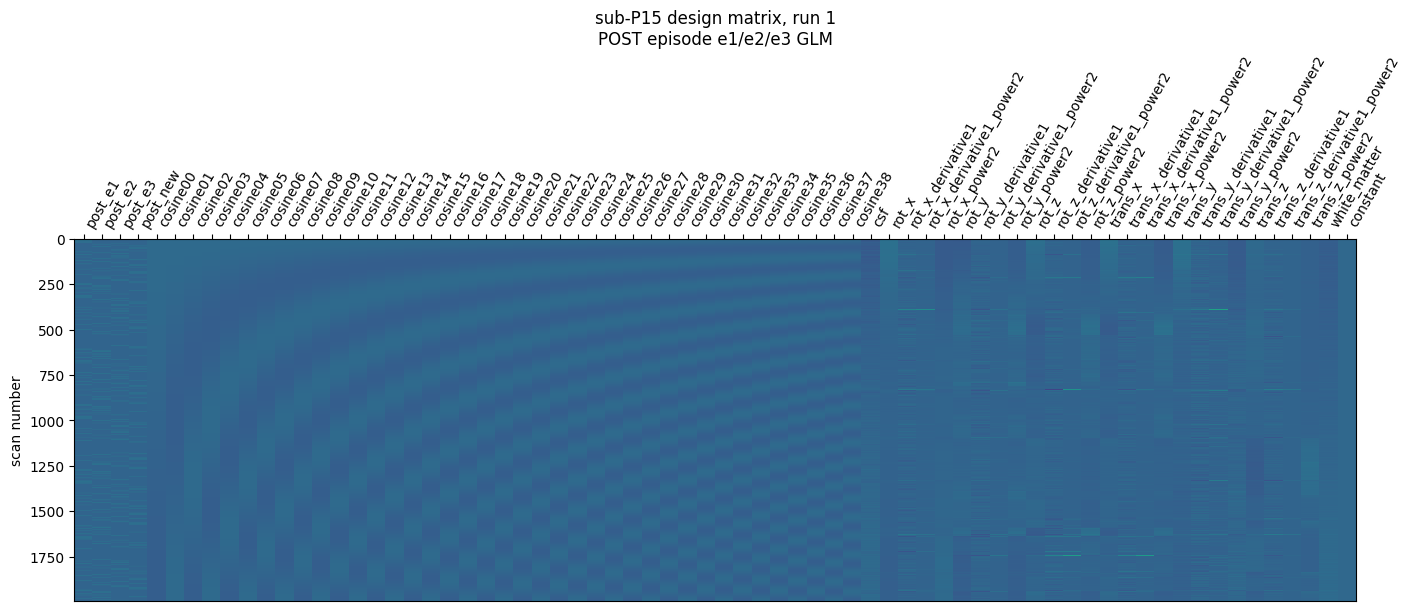

Saved design matrix CSV: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/tables/design_matrices/post_episode_e1_e2_e3_viewing_glm_sub-P15_run-1_design_matrix_smoothed5mm.csv
Saved design matrix figure: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/figures/design_matrices/post_episode_e1_e2_e3_viewing_glm_sub-P15_run-1_design_matrix_smoothed5mm.png
Design and contrast-vector preview passed.


In [5]:
# ============================================================
# 5. Single-subject design and contrast preview
# ============================================================

preview_result = run_post_episode_first_level_subject(
    subject=TEST_SUBJECT,
    paths=paths,
    viewing_item_labels=viewing_item_labels,
    contrast_specs=contrast_specs,
    output_dirs=dirs,
    sessions=sessions,
    smoothing_fwhm=SMOOTHING_FWHM,
    smoothing_label=SMOOTHING_LABEL,
    hrf_model="spm",
    save_outputs=False,
    make_design_plot=False,
    return_model=True,
)

preview_subject_qc = preview_result["subject_qc"]
preview_contrast_qc = preview_result["contrast_qc"]
design_matrices = preview_result["design_matrices"]

preview_subject_qc_path = (
    dirs["tables"]
    / f"{ANALYSIS_NAME}_{TEST_SUBJECT}_design_preview_subject_qc.csv"
)
preview_contrast_qc_path = (
    dirs["tables"]
    / f"{ANALYSIS_NAME}_{TEST_SUBJECT}_contrast_vector_preview_qc.csv"
)

preview_subject_qc.to_csv(preview_subject_qc_path, index=False)
preview_contrast_qc.to_csv(preview_contrast_qc_path, index=False)

print("Subject QC preview:")
display(preview_subject_qc)

print("Contrast-vector preview:")
display(preview_contrast_qc)

assert not preview_contrast_qc.groupby("contrast")["is_null_vector"].all().any()

design_matrix_dir = dirs["figures"] / "design_matrices"
design_matrix_dir.mkdir(parents=True, exist_ok=True)

design_matrix_table_dir = dirs["tables"] / "design_matrices"
design_matrix_table_dir.mkdir(parents=True, exist_ok=True)

for run_idx, design_matrix in enumerate(design_matrices, start=1):
    print("=" * 80)
    print(f"{TEST_SUBJECT} — design matrix run {run_idx}")
    print("Shape:", design_matrix.shape)

    task_columns = [
        col for col in design_matrix.columns
        if col.startswith("post_")
    ]

    print("Task regressors:")
    print(task_columns)

    design_matrix_csv_path = (
        design_matrix_table_dir
        / f"{ANALYSIS_NAME}_{TEST_SUBJECT}_run-{run_idx}_design_matrix_{SMOOTHING_LABEL}.csv"
    )
    design_matrix.to_csv(design_matrix_csv_path)

    # This Nilearn version does not support ax=..., so use plt.gcf().
    plot_design_matrix(design_matrix)
    fig = plt.gcf()
    fig.set_size_inches(14, 6)

    plt.title(
        f"{TEST_SUBJECT} design matrix, run {run_idx}\n"
        "POST episode e1/e2/e3 GLM"
    )

    design_matrix_fig_path = (
        design_matrix_dir
        / f"{ANALYSIS_NAME}_{TEST_SUBJECT}_run-{run_idx}_design_matrix_{SMOOTHING_LABEL}.png"
    )

    fig.savefig(design_matrix_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved design matrix CSV:", design_matrix_csv_path)
    print("Saved design matrix figure:", design_matrix_fig_path)

print("Design and contrast-vector preview passed.")


## Restart-safe first-level GLM

The first-level GLM is the slow part. This notebook is configured so that:

- `RUN_FIRST_LEVEL=True` fits first-level models and saves maps immediately;
- `RUN_FIRST_LEVEL=False` loads/verifies existing maps;
- `OVERWRITE_FIRST_LEVEL=False` runs only missing or incomplete subjects.

After a successful first run, keep `RUN_FIRST_LEVEL=False`.


In [6]:
# ============================================================
# 6. Run, recover, or load first-level GLM results
# ============================================================

first_level_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_qc_{SMOOTHING_LABEL}.csv"
first_level_contrast_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_contrast_qc_{SMOOTHING_LABEL}.csv"
failed_subjects_path = dirs["tables"] / f"{ANALYSIS_NAME}_failed_subjects_{SMOOTHING_LABEL}.csv"
map_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_map_qc_{SMOOTHING_LABEL}.csv"


def subject_has_all_first_level_maps(subject, contrast_specs, dirs, smoothing_label):
    for contrast_name in contrast_specs.keys():
        z_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="z")
        effect_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="effect")
        if not z_path.exists() or not effect_path.exists():
            return False
    return True


def recover_first_level_qc_from_saved_maps(subjects, contrast_specs, dirs, smoothing_label):
    recovered_map_rows = []
    recovered_qc_rows = []
    recovered_contrast_rows = []

    for subject in subjects:
        subject_all_maps_exist = True
        for contrast_name in contrast_specs.keys():
            z_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="z")
            effect_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="effect")

            z_exists = z_path.exists()
            effect_exists = effect_path.exists()
            if not z_exists or not effect_exists:
                subject_all_maps_exist = False

            recovered_map_rows.append({
                "contrast": contrast_name,
                "n_z_maps": int(z_exists),
                "n_effect_maps": int(effect_exists),
                "missing_z_maps": "" if z_exists else subject,
                "missing_effect_maps": "" if effect_exists else subject,
            })

            recovered_contrast_rows.append({
                "subject": subject,
                "contrast": contrast_name,
                "z_map_path": str(z_path),
                "effect_map_path": str(effect_path),
                "z_map_exists": z_exists,
                "effect_map_exists": effect_exists,
                "recovered_from_saved_maps": True,
            })

        recovered_qc_rows.append({
            "subject": subject,
            "all_expected_first_level_maps_exist": subject_all_maps_exist,
            "recovered_from_saved_maps": True,
        })

    first_level_qc = pd.DataFrame(recovered_qc_rows)
    first_level_contrast_qc = pd.DataFrame(recovered_contrast_rows)

    failed_subjects = first_level_qc.loc[
        ~first_level_qc["all_expected_first_level_maps_exist"],
        ["subject"],
    ].copy()

    if len(failed_subjects) > 0:
        failed_subjects["error_type"] = "MissingFirstLevelMaps"
        failed_subjects["error_message"] = "At least one expected first-level z/effect map is missing."
    else:
        failed_subjects = pd.DataFrame(columns=["subject", "error_type", "error_message"])

    return first_level_qc, first_level_contrast_qc, failed_subjects


existing_subjects = [
    subject
    for subject in subjects
    if subject_has_all_first_level_maps(subject, contrast_specs, dirs, SMOOTHING_LABEL)
]
missing_subjects = [subject for subject in subjects if subject not in existing_subjects]

print("Existing complete first-level subjects:", len(existing_subjects))
print("Missing/incomplete first-level subjects:", len(missing_subjects))
if missing_subjects:
    print("Missing/incomplete:", missing_subjects)

if RUN_FIRST_LEVEL:
    if OVERWRITE_FIRST_LEVEL:
        subjects_to_run = subjects
        print("\nOVERWRITE_FIRST_LEVEL=True, rerunning all subjects.")
    else:
        subjects_to_run = missing_subjects
        print("\nOVERWRITE_FIRST_LEVEL=False, running only missing/incomplete subjects.")

    first_level_qc_rows = []
    first_level_contrast_qc_rows = []
    failed_rows = []

    for subject in subjects_to_run:
        print("=" * 80)
        print("Running POST episode first-level GLM:", subject)
        try:
            subject_qc, contrast_qc = run_post_episode_first_level_subject(
                subject=subject,
                paths=paths,
                viewing_item_labels=viewing_item_labels,
                contrast_specs=contrast_specs,
                output_dirs=dirs,
                sessions=sessions,
                smoothing_fwhm=SMOOTHING_FWHM,
                smoothing_label=SMOOTHING_LABEL,
                hrf_model="spm",
                save_outputs=True,
                make_design_plot=False,
            )
            first_level_qc_rows.append(subject_qc)
            first_level_contrast_qc_rows.append(contrast_qc)
            print("Finished:", subject)
        except Exception as exc:
            failed_rows.append({
                "subject": subject,
                "error_type": type(exc).__name__,
                "error_message": str(exc),
            })
            print("FAILED:", subject, type(exc).__name__, str(exc))

    new_first_level_qc = pd.concat(first_level_qc_rows, ignore_index=True) if first_level_qc_rows else pd.DataFrame()
    new_first_level_contrast_qc = pd.concat(first_level_contrast_qc_rows, ignore_index=True) if first_level_contrast_qc_rows else pd.DataFrame()
    failed_subjects = pd.DataFrame(failed_rows)

    if first_level_qc_path.exists() and not OVERWRITE_FIRST_LEVEL:
        old_first_level_qc = pd.read_csv(first_level_qc_path)
        first_level_qc = pd.concat([old_first_level_qc, new_first_level_qc], ignore_index=True)
        if "subject" in first_level_qc.columns:
            first_level_qc = first_level_qc.drop_duplicates(subset=["subject"], keep="last")
    else:
        first_level_qc = new_first_level_qc

    if first_level_contrast_qc_path.exists() and not OVERWRITE_FIRST_LEVEL:
        old_first_level_contrast_qc = pd.read_csv(first_level_contrast_qc_path)
        first_level_contrast_qc = pd.concat([old_first_level_contrast_qc, new_first_level_contrast_qc], ignore_index=True)
        dedup_cols = [col for col in ["subject", "contrast", "run"] if col in first_level_contrast_qc.columns]
        if dedup_cols:
            first_level_contrast_qc = first_level_contrast_qc.drop_duplicates(subset=dedup_cols, keep="last")
    else:
        first_level_contrast_qc = new_first_level_contrast_qc

    first_level_qc.to_csv(first_level_qc_path, index=False)
    first_level_contrast_qc.to_csv(first_level_contrast_qc_path, index=False)
    failed_subjects.to_csv(failed_subjects_path, index=False)
else:
    print("\nRUN_FIRST_LEVEL=False, loading or recovering existing first-level outputs.")
    if first_level_qc_path.exists() and first_level_contrast_qc_path.exists():
        first_level_qc = pd.read_csv(first_level_qc_path)
        first_level_contrast_qc = pd.read_csv(first_level_contrast_qc_path)
        failed_subjects = pd.read_csv(failed_subjects_path) if failed_subjects_path.exists() else pd.DataFrame(columns=["subject", "error_type", "error_message"])
    else:
        print("QC tables missing; recovering from saved first-level maps.")
        first_level_qc, first_level_contrast_qc, failed_subjects = recover_first_level_qc_from_saved_maps(
            subjects, contrast_specs, dirs, SMOOTHING_LABEL
        )
        first_level_qc.to_csv(first_level_qc_path, index=False)
        first_level_contrast_qc.to_csv(first_level_contrast_qc_path, index=False)
        failed_subjects.to_csv(failed_subjects_path, index=False)

map_qc = verify_first_level_maps(subjects, contrast_specs, dirs, SMOOTHING_LABEL)
map_qc.to_csv(map_qc_path, index=False)

display(map_qc)
assert (map_qc["n_z_maps"] == len(subjects)).all(), (
    "Some first-level z-maps are missing. Set RUN_FIRST_LEVEL=True and OVERWRITE_FIRST_LEVEL=False."
)
assert (map_qc["n_effect_maps"] == len(subjects)).all(), (
    "Some first-level effect maps are missing. Set RUN_FIRST_LEVEL=True and OVERWRITE_FIRST_LEVEL=False."
)

print("\nFirst-level ready.")
print("Failed subjects:", len(failed_subjects))
display(first_level_qc)
display(failed_subjects)
assert len(failed_subjects) == 0, "Some subjects failed. Inspect failed_subjects."


Existing complete first-level subjects: 0
Missing/incomplete first-level subjects: 27
Missing/incomplete: ['sub-P10', 'sub-P12', 'sub-P13', 'sub-P14', 'sub-P15', 'sub-P16', 'sub-P17', 'sub-P18', 'sub-P19', 'sub-P21', 'sub-P22', 'sub-P23', 'sub-P25', 'sub-P27', 'sub-P31', 'sub-P34', 'sub-P35', 'sub-P36', 'sub-P41', 'sub-P42', 'sub-P43', 'sub-P44', 'sub-P45', 'sub-P47', 'sub-P48', 'sub-P50', 'sub-P51']

OVERWRITE_FIRST_LEVEL=True, rerunning all subjects.
Running POST episode first-level GLM: sub-P10
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: sub-P10
Running POST episode first-level GLM: sub-P12
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: sub-P12
Running POST episode first-level GLM: sub-P13
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
Finished: sub-P13
Running POST episode first-level GLM: sub-P14
[FirstLevelModel.fit] A 'modu

,contrast,priority,n_subjects,n_z_maps,n_effect_maps
0,post_e1_gt_new,06_episode_vs_new,27,27,27
1,post_e2_gt_new,06_episode_vs_new,27,27,27
2,post_e3_gt_new,06_episode_vs_new,27,27,27
3,post_episode_old_gt_new_avg,06_episode_average_old_vs_new,27,27,27
4,post_e1_gt_e2,06_episode_pairwise,27,27,27
5,post_e2_gt_e1,06_episode_pairwise,27,27,27
6,post_e1_gt_e3,06_episode_pairwise,27,27,27
7,post_e3_gt_e1,06_episode_pairwise,27,27,27
8,post_e2_gt_e3,06_episode_pairwise,27,27,27
9,post_e3_gt_e2,06_episode_pairwise,27,27,27



First-level ready.
Failed subjects: 0


,subject,phase,session,tr,n_scans,n_events,event_types,n_confounds,sample_mask_originally_none,sample_masks_passed_to_nilearn,n_design_columns,design_columns
0,sub-P10,post,ses-05,1.3,1994,384,post_e1;post_e2;post_e3;post_new,65,True,False,70,post_e1;post_e2;post_e3;post_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15...
1,sub-P12,post,ses-05,1.3,1954,384,post_e1;post_e2;post_e3;post_new,64,True,False,69,post_e1;post_e2;post_e3;post_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15...
2,sub-P13,post,ses-05,1.3,1957,384,post_e1;post_e2;post_e3;post_new,64,True,False,69,post_e1;post_e2;post_e3;post_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15...
3,sub-P14,post,ses-05,1.3,1922,384,post_e1;post_e2;post_e3;post_new,64,True,False,69,post_e1;post_e2;post_e3;post_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15...
4,sub-P15,post,ses-05,1.3,1995,384,post_e1;post_e2;post_e3;post_new,65,True,False,70,post_e1;post_e2;post_e3;post_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15...
5,sub-P16,post,ses-05,1.3,1955,384,post_e1;post_e2;post_e3;post_new,64,True,False,69,post_e1;post_e2;post_e3;post_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15...
6,sub-P17,post,ses-05,1.3,1946,384,post_e1;post_e2;post_e3;post_new,64,True,False,69,post_e1;post_e2;post_e3;post_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15...
7,sub-P18,post,ses-05,1.3,1993,384,post_e1;post_e2;post_e3;post_new,65,True,False,70,post_e1;post_e2;post_e3;post_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15...
8,sub-P19,post,ses-05,1.3,1945,384,post_e1;post_e2;post_e3;post_new,64,True,False,69,post_e1;post_e2;post_e3;post_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15...
9,sub-P21,post,ses-05,1.3,1961,384,post_e1;post_e2;post_e3;post_new,64,True,False,69,post_e1;post_e2;post_e3;post_new;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cosine14;cosine15...


""


## Verify first-level maps

Each contrast should have one z-map and one effect-size map per subject.


In [7]:
# ============================================================
# 7. Verify first-level maps
# ============================================================

map_qc = verify_first_level_maps(subjects, contrast_specs, dirs, SMOOTHING_LABEL)
map_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_map_qc_{SMOOTHING_LABEL}.csv"
map_qc.to_csv(map_qc_path, index=False)

display(map_qc)
print("Saved:", map_qc_path)

assert (map_qc["n_z_maps"] == len(subjects)).all()
assert (map_qc["n_effect_maps"] == len(subjects)).all()


,contrast,priority,n_subjects,n_z_maps,n_effect_maps
0,post_e1_gt_new,06_episode_vs_new,27,27,27
1,post_e2_gt_new,06_episode_vs_new,27,27,27
2,post_e3_gt_new,06_episode_vs_new,27,27,27
3,post_episode_old_gt_new_avg,06_episode_average_old_vs_new,27,27,27
4,post_e1_gt_e2,06_episode_pairwise,27,27,27
5,post_e2_gt_e1,06_episode_pairwise,27,27,27
6,post_e1_gt_e3,06_episode_pairwise,27,27,27
7,post_e3_gt_e1,06_episode_pairwise,27,27,27
8,post_e2_gt_e3,06_episode_pairwise,27,27,27
9,post_e3_gt_e2,06_episode_pairwise,27,27,27


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/tables/post_episode_e1_e2_e3_viewing_glm_first_level_map_qc_smoothed5mm.csv


## Second-level GLM

At the group level, each first-level effect map enters a one-sample test against zero.


In [8]:
# ============================================================
# 8. Run or load second-level GLM
# ============================================================

second_level_table_path = dirs["tables"] / f"{ANALYSIS_NAME}_second_level_maps_{SMOOTHING_LABEL}.csv"

if RUN_SECOND_LEVEL:
    if second_level_table_path.exists() and not OVERWRITE_SECOND_LEVEL:
        print("RUN_SECOND_LEVEL=True but existing second-level table found.")
        print("OVERWRITE_SECOND_LEVEL=False, loading existing second-level maps.")
        second_level_table = pd.read_csv(second_level_table_path)
    else:
        print("Running second-level GLM.")
        second_level_table = run_second_level_all_contrasts(
            subjects=subjects,
            contrast_specs=contrast_specs,
            output_dirs=dirs,
            smoothing_label=SMOOTHING_LABEL,
        )
        second_level_table.to_csv(second_level_table_path, index=False)
else:
    print("RUN_SECOND_LEVEL=False, loading existing second-level table.")
    assert second_level_table_path.exists(), (
        f"Missing second-level table: {second_level_table_path}. "
        "Set RUN_SECOND_LEVEL=True once to generate it."
    )
    second_level_table = pd.read_csv(second_level_table_path)

display(second_level_table)
print("Second-level table:", second_level_table_path)

assert second_level_table["z_map_exists"].all()
assert second_level_table["effect_map_exists"].all()


Running second-level GLM.


,contrast,priority,formula,n_subjects,z_map_path,effect_map_path,z_map_exists,effect_map_exists
0,post_e1_gt_new,06_episode_vs_new,"$$\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,new}}$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/maps/group_post_e1_gt_new_s...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/maps/group_post_e1_gt_new_s...,True,True
1,post_e2_gt_new,06_episode_vs_new,"$$\beta_{\mathrm{post,e2}}-\beta_{\mathrm{post,new}}$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/maps/group_post_e2_gt_new_s...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/maps/group_post_e2_gt_new_s...,True,True
2,post_e3_gt_new,06_episode_vs_new,"$$\beta_{\mathrm{post,e3}}-\beta_{\mathrm{post,new}}$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/maps/group_post_e3_gt_new_s...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/maps/group_post_e3_gt_new_s...,True,True
3,post_episode_old_gt_new_avg,06_episode_average_old_vs_new,"$$\frac{1}{3}(\beta_{\mathrm{post,e1}}+\beta_{\mathrm{post,e2}}+\beta_{\mathrm{post,e3}})-\beta_{\mathrm{post,new}}$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/maps/group_post_episode_old...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/maps/group_post_episode_old...,True,True
4,post_e1_gt_e2,06_episode_pairwise,"$$\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,e2}}$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/maps/group_post_e1_gt_e2_sm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/maps/group_post_e1_gt_e2_sm...,True,True
5,post_e2_gt_e1,06_episode_pairwise,"$$\beta_{\mathrm{post,e2}}-\beta_{\mathrm{post,e1}}$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/maps/group_post_e2_gt_e1_sm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/maps/group_post_e2_gt_e1_sm...,True,True
6,post_e1_gt_e3,06_episode_pairwise,"$$\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,e3}}$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/maps/group_post_e1_gt_e3_sm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/maps/group_post_e1_gt_e3_sm...,True,True
7,post_e3_gt_e1,06_episode_pairwise,"$$\beta_{\mathrm{post,e3}}-\beta_{\mathrm{post,e1}}$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/maps/group_post_e3_gt_e1_sm...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/maps/group_post_e3_gt_e1_sm...,True,True
8,post_e2_gt_e3,06_episode_pairwise,"$$\beta_{\mathrm{post,e2}}-\beta_{\mathrm{post,e3}}$$",27,/

Second-level table: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/tables/post_episode_e1_e2_e3_viewing_glm_second_level_maps_smoothed5mm.csv


## Thresholding and cluster tables

We save corrected threshold summaries and exploratory cluster tables. Visualizations use exploratory thresholds unless corrected maps survive FDR/Bonferroni.


In [9]:
# ============================================================
# 9. Threshold maps and create cluster tables
# ============================================================

threshold_summary = threshold_group_maps(second_level_table, dirs)
threshold_summary_path = dirs["tables"] / f"{ANALYSIS_NAME}_threshold_summary_{SMOOTHING_LABEL}.csv"
threshold_summary.to_csv(threshold_summary_path, index=False)

cluster_summary, cluster_details = make_cluster_tables(
    second_level_table=second_level_table,
    output_dirs=dirs,
    thresholds=(2.33, 3.0),
    cluster_threshold_voxels=10,
)

cluster_summary_path = dirs["tables"] / f"{ANALYSIS_NAME}_cluster_summary_{SMOOTHING_LABEL}.csv"
cluster_details_path = dirs["tables"] / f"{ANALYSIS_NAME}_cluster_details_{SMOOTHING_LABEL}.csv"
cluster_summary.to_csv(cluster_summary_path, index=False)
cluster_details.to_csv(cluster_details_path, index=False)

print("Threshold summary:")
display(threshold_summary.sort_values(["contrast", "threshold_label"]))

print("Cluster summary:")
display(cluster_summary.sort_values(["contrast", "threshold_label"]))

print("Saved:")
print(threshold_summary_path)
print(cluster_summary_path)
print(cluster_details_path)


/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: FutureWarning: 
From nilearn version>=0.15, the default 'threshold' will be set to 3.090232306167813.
  thresholded_img, z_threshold = threshold_stats_img(
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: UserWarning: The given float value must not exceed 4.646433353424072. But, you have given threshold=inf.
  thresholded_img, z_threshold = threshold_stats_img(
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: UserWarning: The given float value must not exceed 4.646433353424072. But, you have given threshold=inf.
  thresholded_img, z_threshold = threshold_stats_img(
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: UserWarning: The given float value must not exceed 4.646433353424072. But, you have given threshold=4.944046259789629.
  t

Threshold summary:


/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:133: UserWarning: No clusters found with stat higher than 3.0
  table = get_clusters_table(
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:231: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(all_tables, ignore_index=True)


,contrast,priority,formula,threshold_label,height_control,alpha,two_sided,z_threshold,n_nonzero_voxels,max_z,thresholded_map_path
19,post_e1_gt_e2,06_episode_pairwise,"$$\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,e2}}$$",bonferroni_p05_one_sided,bonferroni,0.050,False,4.944046,1,5.008270,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_post...
17,post_e1_gt_e2,06_episode_pairwise,"$$\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,e2}}$$",fdr_q05_one_sided,fdr,0.050,False,5.008270,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_post...
18,post_e1_gt_e2,06_episode_pairwise,"$$\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,e2}}$$",fdr_q10_one_sided,fdr,0.100,False,5.008270,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_post...
16,post_e1_gt_e2,06_episode_pairwise,"$$\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,e2}}$$",uncorrected_p001_one_sided,uncorrected,0.001,False,3.000000,256,5.008270,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_post...
27,post_e1_gt_e3,06_episode_pairwise,"$$\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,e3}}$$",bonferroni_p05_one_sided,bonferroni,0.050,False,4.944046,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_post...
25,post_e1_gt_e3,06_episode_pairwise,"$$\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,e3}}$$",fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_post...
26,post_e1_gt_e3,06_episode_pairwise,"$$\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,e3}}$$",fdr_q10_one_sided,fdr,0.100,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_post...
24,post_e1_gt_e3,06_episode_pairwise,"$$\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,e3}}$$",uncorrected_p001_one_sided,uncorrected,0.001,False,3.000000,196,4.683642,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_post...
3,post_e1_gt_new,06_episode_vs_new,"$$\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,new}}$$",bonferroni_p05_one_sided,bonferroni,0.050,False,4.944046,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_post...
1,post_e1_gt_new,06_episode_vs_new,"$$\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,new}}$$",fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/thresholded_maps/group_post...


Cluster summary:


,contrast,priority,threshold_label,stat_threshold,cluster_threshold_voxels,n_clusters,max_peak_stat,largest_cluster_mm3,cluster_table_path
8,post_e1_gt_e2,06_episode_pairwise,z_gt_2.33,2.33,10,62,5.008270,1109.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/cluster_tables/clusters_pos...
9,post_e1_gt_e2,06_episode_pairwise,z_gt_3.00,3.00,10,2,4.361884,218.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/cluster_tables/clusters_pos...
12,post_e1_gt_e3,06_episode_pairwise,z_gt_2.33,2.33,10,37,4.683642,1328.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/cluster_tables/clusters_pos...
13,post_e1_gt_e3,06_episode_pairwise,z_gt_3.00,3.00,10,1,3.686133,156.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/cluster_tables/clusters_pos...
0,post_e1_gt_new,06_episode_vs_new,z_gt_2.33,2.33,10,32,4.646433,1187.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/cluster_tables/clusters_pos...
1,post_e1_gt_new,06_episode_vs_new,z_gt_3.00,3.00,10,2,4.406915,343.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/cluster_tables/clusters_pos...
10,post_e2_gt_e1,06_episode_pairwise,z_gt_2.33,2.33,10,5,3.627818,390.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/cluster_tables/clusters_pos...
11,post_e2_gt_e1,06_episode_pairwise,z_gt_3.00,3.00,10,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/cluster_tables/clusters_pos...
16,post_e2_gt_e3,06_episode_pairwise,z_gt_2.33,2.33,10,9,3.969816,453.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/cluster_tables/clusters_pos...
17,post_e2_gt_e3,06_episode_pairwise,z_gt_3.00,3.00,10,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/second_level_from_smoothed5mm/cluster_tables/clusters_pos...


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/tables/post_episode_e1_e2_e3_viewing_glm_threshold_summary_smoothed5mm.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/tables/post_episode_e1_e2_e3_viewing_glm_cluster_summary_smoothed5mm.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/tables/post_episode_e1_e2_e3_viewing_glm_cluster_details_smoothed5mm.csv


## Atlas labels for exploratory peaks

The cluster table is labelled with Harvard-Oxford. These labels are useful for reporting, but exact anatomy should still be checked visually.


In [10]:
# ============================================================
# 10. Label cluster table with Harvard-Oxford atlas
# ============================================================

cluster_details_labeled = label_cluster_table(cluster_details)
cluster_details_labeled_path = dirs["tables"] / f"{ANALYSIS_NAME}_cluster_details_labeled_{SMOOTHING_LABEL}.csv"
cluster_details_labeled.to_csv(cluster_details_labeled_path, index=False)

display(cluster_details_labeled.head(80))
print("Saved:", cluster_details_labeled_path)


[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels,harvard_oxford_cortical_label,harvard_oxford_cortical_value,harvard_oxford_subcortical_label,harvard_oxford_subcortical_value
0,1,-46.0,-44.5,17.0,4.646433,265.0,post_e1_gt_new,06_episode_vs_new,"$$\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,new}}$$",z_gt_2.33,2.33,10,Background,0,Left Cerebral White Matter,1
1,2,-21.0,0.5,62.0,4.406915,531.0,post_e1_gt_new,06_episode_vs_new,"$$\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,new}}$$",z_gt_2.33,2.33,10,Superior Frontal Gyrus,3,Left Cerebral Cortex,2
2,3,-18.5,-74.5,47.0,4.105895,1187.0,post_e1_gt_new,06_episode_vs_new,"$$\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,new}}$$",z_gt_2.33,2.33,10,"Lateral Occipital Cortex, superior division",22,Left Cerebral Cortex,2
3,3a,-26.0,-77.0,49.5,2.453721,NaN,post_e1_gt_new,06_episode_vs_new,"$$\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,new}}$$",z_gt_2.33,2.33,10,"Lateral Occipital Cortex, superior division",22,Left Cerebral Cortex,2
4,4,36.5,-72.0,4.5,3.966138,437.0,post_e1_gt_new,06_episode_vs_new,"$$\beta_{\mathrm{post,e1}}-\beta_{\mathrm{post,new}}$$",z_gt_2.33,2.33,10,Background,0,Right Cerebral White Matter,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,15a,-3.5,-94.5,17.0,2.619545,NaN,post_e3_gt_new,06_episode_vs_new,"$$\beta_{\mathrm{post,e3}}-\beta_{\mathrm{post,new}}$$",z_gt_2.33,2.33,10,Occipital Pole,48,Left Cerebral Cortex,2
76,1,-18.5,-74.5,44.5,4.527149,406.0,post_episode_old_gt_new_avg,06_episode_average_old_vs_new,"$$\frac{1}{3}(\beta_{\mathrm{post,e1}}+\beta_{\mathrm{post,e2}}+\beta_{\mathrm{post,e3}})-\beta_{\mathrm{post,new}}$$",z_gt_2.33,2.33,10,"Lateral Occipital Cortex, superior division",22,Left Cerebral Cortex,2
77,2,-23.5,0.5,62.0,4.132599,390.0,post_episode_old_gt_new_avg,06_episode_average_old_vs_new,"$$\frac{1}{3}(\beta_{\mathrm{post,e1}}+\beta_{\mathrm{post,e2}}+\beta_{\mathrm{post,e3}})-\beta_{\mathrm{post,new}}$$",z_gt_2.33,2.33,10,Superior Frontal Gyrus,3,Left Cerebral Cortex,2
78,3,-16.0,-12.0,-13.0,3.923856,156.0,post_episode_old_gt_new_avg,06_episode_average_old_vs_new,"$$\frac{1}{3}(\beta_{\mathrm{post,e1}}+\beta_{\mathrm{post,e2}}+\beta_{\mathrm{post,e3}})-\beta_{\mathrm{post,new}}$$",z_gt_2.33,2.33,10,Background,0,Left Cerebral White Matter,1


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/tables/post_episode_e1_e2_e3_viewing_glm_cluster_details_labeled_smoothed5mm.csv


## Plot episode contrasts on the common mean T1w background

The high-resolution mean T1w from Notebook 00 is passed directly as `bg_img`. We do **not** manually resample it to the z-map grid.


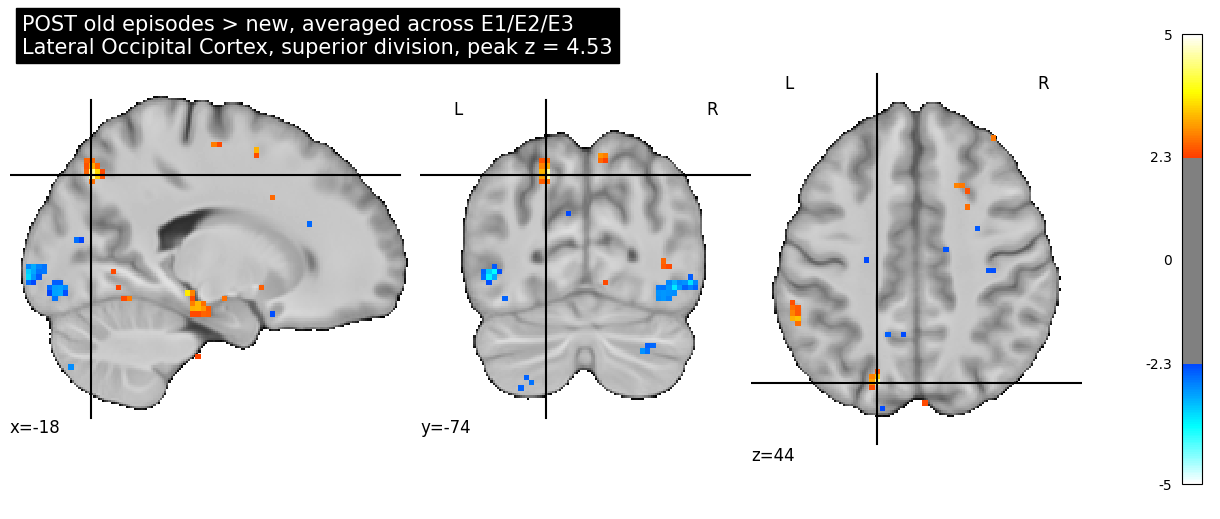

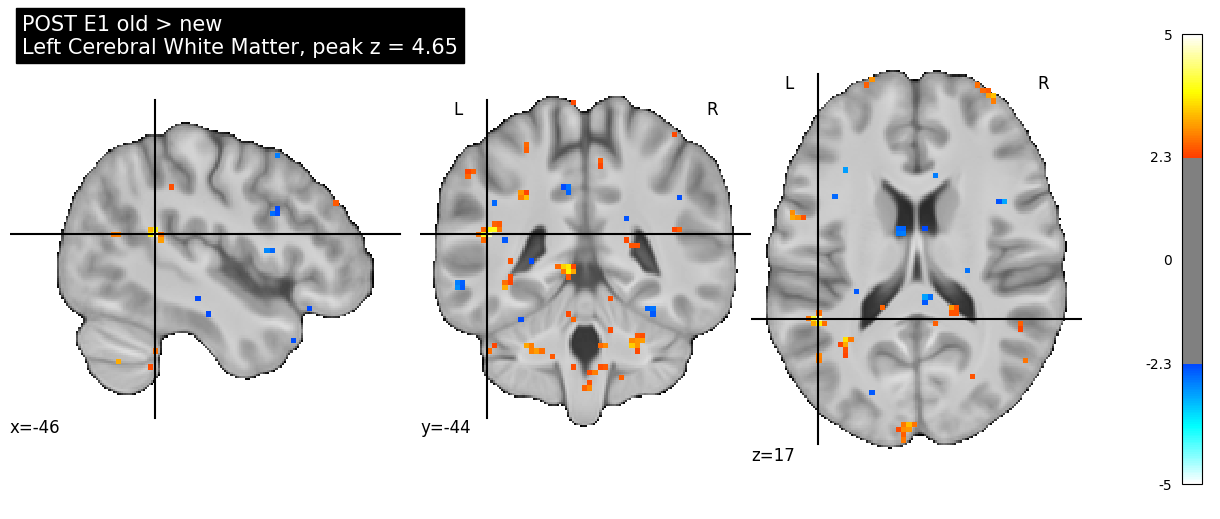

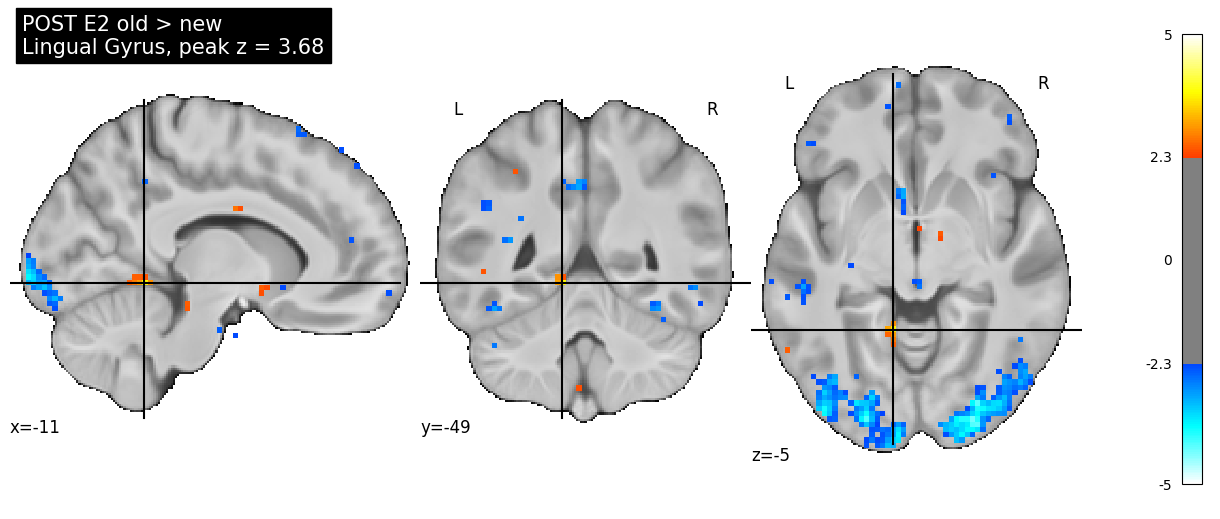

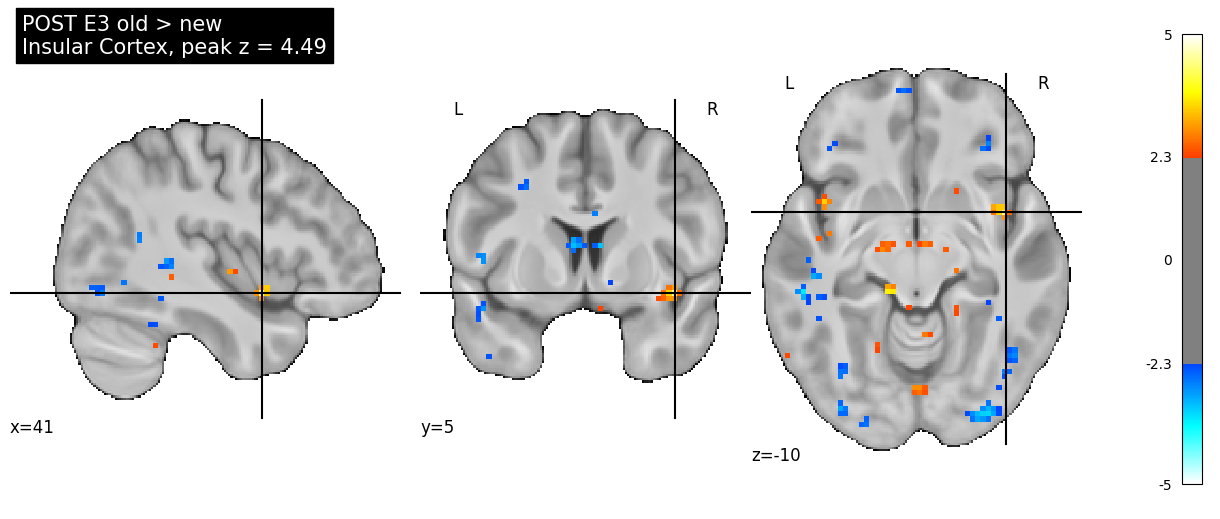

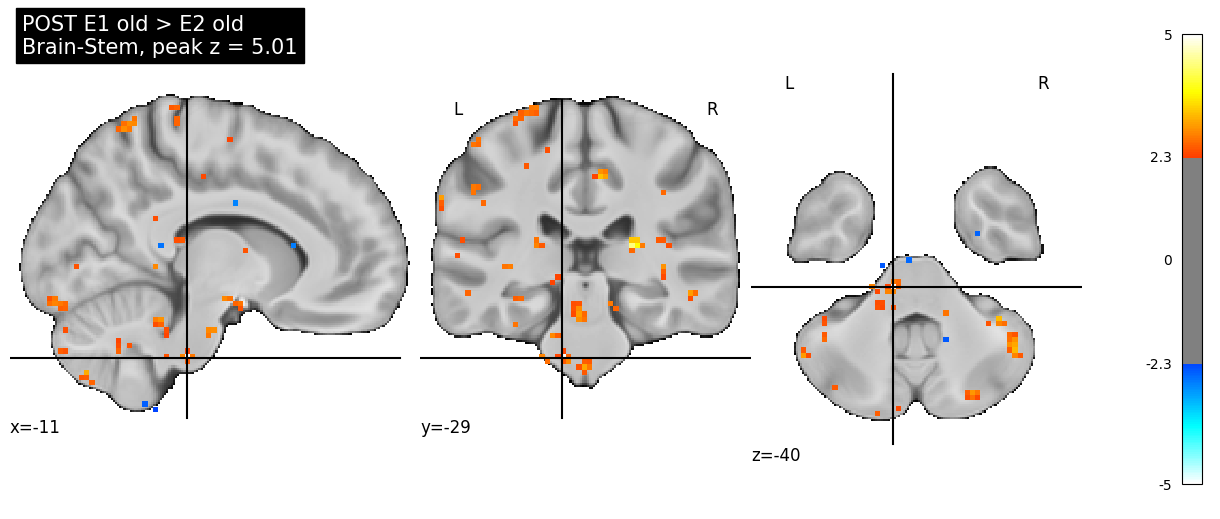

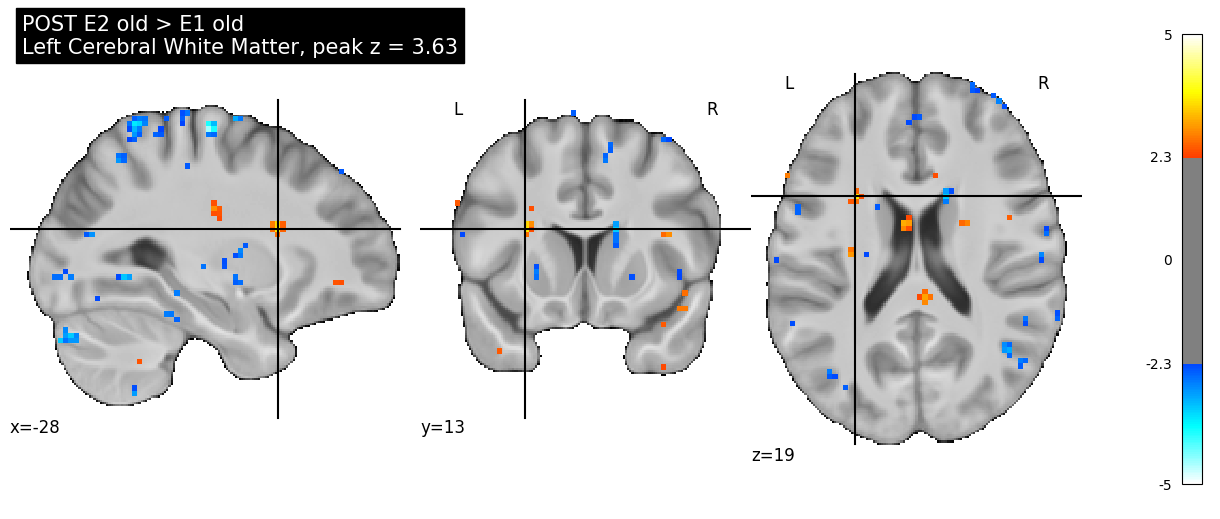

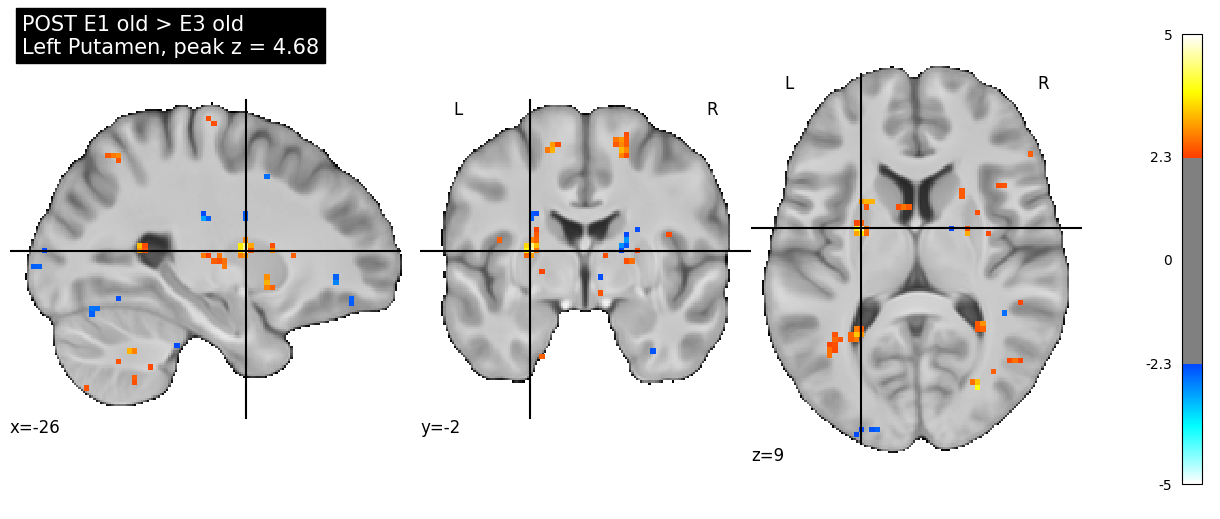

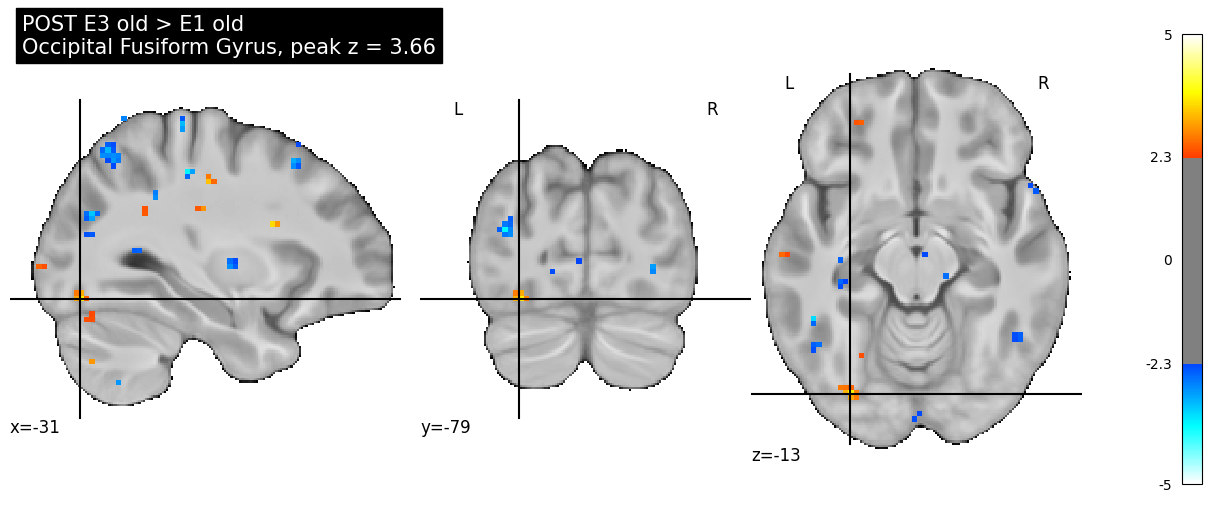

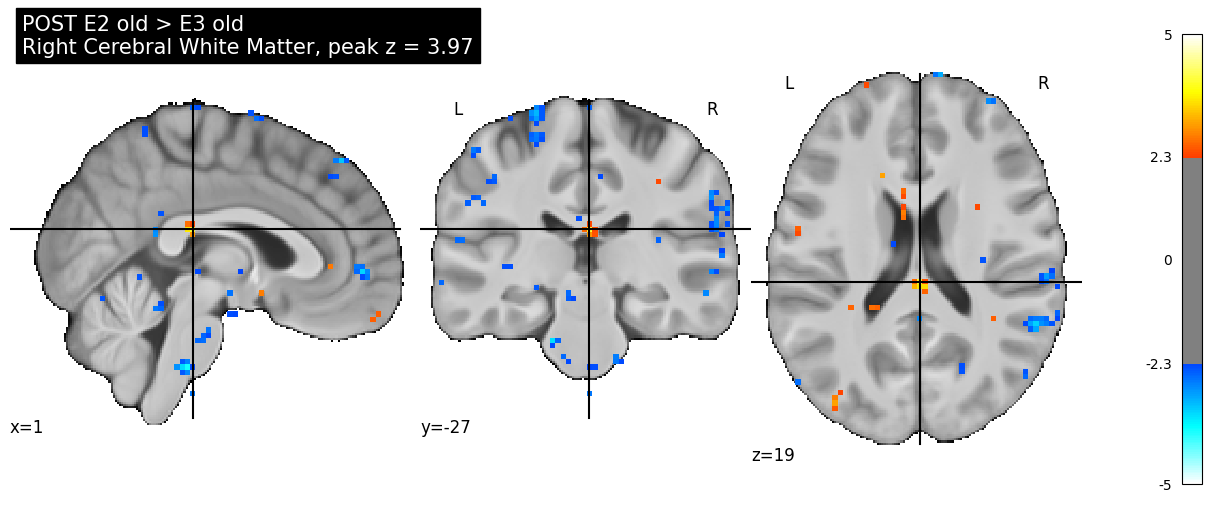

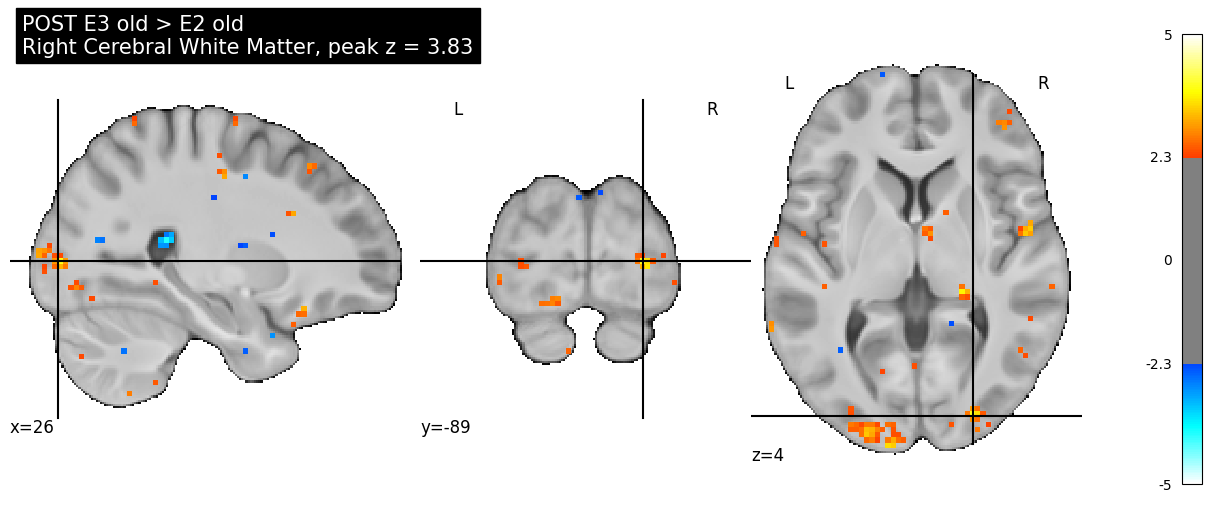

,contrast,figure_path,x,y,z,peak_z,atlas_label,background
0,post_episode_old_gt_new_avg,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/figures/post_episode_e1_e2_e3_viewing_glm_post_episode_ol...,-18.5,-74.5,44.5,4.527149,"Lateral Occipital Cortex, superior division",mean_T1w
1,post_e1_gt_new,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/figures/post_episode_e1_e2_e3_viewing_glm_post_e1_gt_new_...,-46.0,-44.5,17.0,4.646433,Left Cerebral White Matter,mean_T1w
2,post_e2_gt_new,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/figures/post_episode_e1_e2_e3_viewing_glm_post_e2_gt_new_...,-11.0,-49.5,-5.5,3.677072,Lingual Gyrus,mean_T1w
3,post_e3_gt_new,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/figures/post_episode_e1_e2_e3_viewing_glm_post_e3_gt_new_...,41.5,5.5,-10.5,4.485660,Insular Cortex,mean_T1w
4,post_e1_gt_e2,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/figures/post_episode_e1_e2_e3_viewing_glm_post_e1_gt_e2_t...,-11.0,-29.5,-40.5,5.008270,Brain-Stem,mean_T1w
5,post_e2_gt_e1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/figures/post_episode_e1_e2_e3_viewing_glm_post_e2_gt_e1_t...,-28.5,13.0,19.5,3.627818,Left Cerebral White Matter,mean_T1w
6,post_e1_gt_e3,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/figures/post_episode_e1_e2_e3_viewing_glm_post_e1_gt_e3_t...,-26.0,-2.0,9.5,4.683642,Left Putamen,mean_T1w
7,post_e3_gt_e1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/figures/post_episode_e1_e2_e3_viewing_glm_post_e3_gt_e1_t...,-31.0,-79.5,-13.0,3.662056,Occipital Fusiform Gyrus,mean_T1w
8,post_e2_gt_e3,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/figures/post_episode_e1_e2_e3_viewing_glm_post_e2_gt_e3_t...,1.5,-27.0,19.5,3.969816,Right Cerebral White Matter,mean_T1w
9,post_e3_gt_e2,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/figures/post_episode_e1_e2_e3_viewing_glm_post_e3_gt_e2_t...,26.5,-89.5,4.5,3.830189,Right Cerebral White Matter,mean_T1w


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/tables/post_episode_e1_e2_e3_viewing_glm_figure_index_on_mean_T1w_smoothed5mm.csv


In [11]:
# ============================================================
# 11. Plot episode contrasts on mean T1w background
# ============================================================

main_contrasts = [
    "post_episode_old_gt_new_avg",
    "post_e1_gt_new",
    "post_e2_gt_new",
    "post_e3_gt_new",
    "post_e1_gt_e2",
    "post_e2_gt_e1",
    "post_e1_gt_e3",
    "post_e3_gt_e1",
    "post_e2_gt_e3",
    "post_e3_gt_e2",
]

plot_title_map = {
    "post_episode_old_gt_new_avg": "POST old episodes > new, averaged across E1/E2/E3",
    "post_e1_gt_new": "POST E1 old > new",
    "post_e2_gt_new": "POST E2 old > new",
    "post_e3_gt_new": "POST E3 old > new",
    "post_e1_gt_e2": "POST E1 old > E2 old",
    "post_e2_gt_e1": "POST E2 old > E1 old",
    "post_e1_gt_e3": "POST E1 old > E3 old",
    "post_e3_gt_e1": "POST E3 old > E1 old",
    "post_e2_gt_e3": "POST E2 old > E3 old",
    "post_e3_gt_e2": "POST E3 old > E2 old",
}

plot_index_rows = []

for contrast_name in main_contrasts:
    subset = cluster_details_labeled.query(
        "contrast == @contrast_name and threshold_label == 'z_gt_2.33'"
    ).copy()

    if len(subset) == 0:
        print("No z > 2.33 clusters for", contrast_name)
        continue

    top = subset.sort_values("Peak Stat", ascending=False).iloc[0]
    z_map_path = second_level_table.set_index("contrast").loc[contrast_name, "z_map_path"]
    cut_coords = (float(top["X"]), float(top["Y"]), float(top["Z"]))

    atlas_label = top.get("harvard_oxford_cortical_label", "")
    if atlas_label == "Background":
        atlas_label = top.get("harvard_oxford_subcortical_label", "Background")

    title = f"{plot_title_map[contrast_name]}\n{atlas_label}, peak z = {float(top['Peak Stat']):.2f}"
    fig_path = dirs["figures"] / f"{ANALYSIS_NAME}_{contrast_name}_top_peak_on_mean_T1w_{SMOOTHING_LABEL}.png"

    plot_group_stat_map(
        z_map_path=z_map_path,
        cut_coords=cut_coords,
        title=title,
        threshold=2.33,
        vmax=5.0,
        output_path=fig_path,
        bg_img=mean_t1w_img if USE_MEAN_T1W_BACKGROUND else None,
        dim=-0.2,
    )

    plot_index_rows.append({
        "contrast": contrast_name,
        "figure_path": str(fig_path),
        "x": cut_coords[0],
        "y": cut_coords[1],
        "z": cut_coords[2],
        "peak_z": float(top["Peak Stat"]),
        "atlas_label": atlas_label,
        "background": "mean_T1w" if USE_MEAN_T1W_BACKGROUND else "MNI_template",
    })

plot_index = pd.DataFrame(plot_index_rows)
plot_index_path = dirs["tables"] / f"{ANALYSIS_NAME}_figure_index_on_mean_T1w_{SMOOTHING_LABEL}.csv"
plot_index.to_csv(plot_index_path, index=False)

display(plot_index)
print("Saved:", plot_index_path)


## Optional interactive views

These HTML views are useful for inspection but should not be the primary presentation figures.


In [12]:
# ============================================================
# 12. Save optional interactive views
# ============================================================

interactive_rows = []

for contrast_name in main_contrasts:
    z_map_path = second_level_table.set_index("contrast").loc[contrast_name, "z_map_path"]
    html_path = dirs["interactive"] / f"{ANALYSIS_NAME}_{contrast_name}_{SMOOTHING_LABEL}_interactive.html"
    view = make_interactive_view(z_map_path, threshold=2.33, title=plot_title_map[contrast_name])
    view.save_as_html(str(html_path))
    interactive_rows.append({"contrast": contrast_name, "interactive_html_path": str(html_path)})

interactive_index = pd.DataFrame(interactive_rows)
interactive_index_path = dirs["tables"] / f"{ANALYSIS_NAME}_interactive_index_{SMOOTHING_LABEL}.csv"
interactive_index.to_csv(interactive_index_path, index=False)

display(interactive_index)
print("Saved:", interactive_index_path)


/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWa

,contrast,interactive_html_path
0,post_episode_old_gt_new_avg,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/interactive_views/post_episode_e1_e2_e3_viewing_glm_post_...
1,post_e1_gt_new,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/interactive_views/post_episode_e1_e2_e3_viewing_glm_post_...
2,post_e2_gt_new,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/interactive_views/post_episode_e1_e2_e3_viewing_glm_post_...
3,post_e3_gt_new,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/interactive_views/post_episode_e1_e2_e3_viewing_glm_post_...
4,post_e1_gt_e2,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/interactive_views/post_episode_e1_e2_e3_viewing_glm_post_...
5,post_e2_gt_e1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/interactive_views/post_episode_e1_e2_e3_viewing_glm_post_...
6,post_e1_gt_e3,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/interactive_views/post_episode_e1_e2_e3_viewing_glm_post_...
7,post_e3_gt_e1,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/interactive_views/post_episode_e1_e2_e3_viewing_glm_post_...
8,post_e2_gt_e3,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/interactive_views/post_episode_e1_e2_e3_viewing_glm_post_...
9,post_e3_gt_e2,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/interactive_views/post_episode_e1_e2_e3_viewing_glm_post_...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/tables/post_episode_e1_e2_e3_viewing_glm_interactive_index_smoothed5mm.csv


## Notebook conclusion

This notebook provides a structured POST-only episode analysis.

The key outputs are:

- first-level POST episode contrast maps for all N=27 subjects;
- group-level maps for E1/E2/E3 versus new controls;
- all ordered pairwise episode contrasts;
- threshold summaries and cluster tables;
- figures plotted on the common mean T1w background from Notebook 00.

Interpretation should remain cautious: these are exploratory whole-brain episode contrasts unless corrected thresholds are survived.


In [13]:
# ============================================================
# 13. Save analysis manifest
# ============================================================

analysis_manifest = {
    "notebook": "06_post_episode_e1_e2_e3_viewing_glm.ipynb",
    "analysis_name": ANALYSIS_NAME,
    "project_root": str(PROJECT_ROOT),
    "n_subjects": len(subjects),
    "subjects": subjects,
    "smoothing_fwhm": SMOOTHING_FWHM,
    "smoothing_label": SMOOTHING_LABEL,
    "runtime_flags": {
        "RUN_FIRST_LEVEL": RUN_FIRST_LEVEL,
        "OVERWRITE_FIRST_LEVEL": OVERWRITE_FIRST_LEVEL,
        "RUN_SECOND_LEVEL": RUN_SECOND_LEVEL,
        "OVERWRITE_SECOND_LEVEL": OVERWRITE_SECOND_LEVEL,
        "USE_MEAN_T1W_BACKGROUND": USE_MEAN_T1W_BACKGROUND,
    },
    "main_contrasts": {
        name: contrast_specs[name]
        for name in main_contrasts
        if name in contrast_specs
    },
    "key_outputs": {
        "contrast_definitions": str(contrast_table_path),
        "event_qc": str(event_qc_path),
        "all_events": str(all_events_path),
        "first_level_qc": str(first_level_qc_path),
        "first_level_contrast_qc": str(first_level_contrast_qc_path),
        "first_level_map_qc": str(map_qc_path),
        "second_level_table": str(second_level_table_path),
        "threshold_summary": str(threshold_summary_path),
        "cluster_summary": str(cluster_summary_path),
        "cluster_details": str(cluster_details_path),
        "cluster_details_labeled": str(cluster_details_labeled_path),
        "figure_index_on_mean_T1w": str(plot_index_path),
        "interactive_index": str(interactive_index_path),
        "mean_t1w_background": str(mean_t1w_path),
    },
}

analysis_manifest_path = dirs["restart"] / f"{ANALYSIS_NAME}_analysis_manifest.json"
with open(analysis_manifest_path, "w") as f:
    json.dump(analysis_manifest, f, indent=2)

print("Saved analysis manifest:")
print(analysis_manifest_path)


Saved analysis manifest:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/post_episode_e1_e2_e3_viewing_glm/restart/post_episode_e1_e2_e3_viewing_glm_analysis_manifest.json
